In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/dataset_accidentes_limpio.csv")
df.shape

(406540, 13)

In [2]:
df.columns

Index(['MARCA_VEHICULO', 'MODELO_VEHICULO', 'TIPO_VEHICULO', 'EDAD_VEHICULO',
       'FECHA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE', 'DEPARTAMENTO_ACCIDENTE',
       'MUNICIPIO_ACCIDENTE', 'AUTORIDAD_DE_TRANSITO', 'MES', 'AÑO', 'FECHA',
       'SEVERIDAD'],
      dtype='object')

In [3]:
df.head()

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO,MES,AÑO,FECHA,SEVERIDAD
0,HONDA,2017,MOTOCICLETA,9.0,NaN,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12,2025,2025-12-01,0
1,CHEVROLET,2007,CAMION,20.0,NaN,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12,2025,2025-12-01,0
2,JEEP,2017,CAMPERO,9.0,NaN,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12,2025,2025-12-01,0
3,CHEVROLET,2023,CAMIONETA,2.0,NaN,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12,2025,2025-12-01,0
4,HONDA,2026,MOTOCICLETA,1.0,NaN,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12,2025,2025-12-01,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   MARCA_VEHICULO          406496 non-null  object 
 1   MODELO_VEHICULO         406540 non-null  int64  
 2   TIPO_VEHICULO           406540 non-null  object 
 3   EDAD_VEHICULO           406519 non-null  float64
 4   FECHA_ACCIDENTE         0 non-null       float64
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object 
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object 
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object 
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object 
 9   MES                     406540 non-null  int64  
 10  AÑO                     406540 non-null  int64  
 11  FECHA                   406540 non-null  object 
 12  SEVERIDAD               406540 non-null  int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 40.3+ MB


In [5]:
df.isnull().sum()

MARCA_VEHICULO                44
MODELO_VEHICULO                0
TIPO_VEHICULO                  0
EDAD_VEHICULO                 21
FECHA_ACCIDENTE           406540
GRAVEDAD_ACCIDENTE             0
DEPARTAMENTO_ACCIDENTE         0
MUNICIPIO_ACCIDENTE            0
AUTORIDAD_DE_TRANSITO          0
MES                            0
AÑO                            0
FECHA                          0
SEVERIDAD                      0
dtype: int64

In [6]:
import unicodedata

def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = texto.upper().strip()
        texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
        return texto
    return texto

columnas_texto = [
    "TIPO_VEHICULO",
    "DEPARTAMENTO_ACCIDENTE",
    "MUNICIPIO_ACCIDENTE",
    "MARCA_VEHICULO"
]

for col in columnas_texto:
    df[col] = df[col].apply(limpiar_texto)

In [7]:
df.dtypes

MARCA_VEHICULO             object
MODELO_VEHICULO             int64
TIPO_VEHICULO              object
EDAD_VEHICULO             float64
FECHA_ACCIDENTE           float64
GRAVEDAD_ACCIDENTE         object
DEPARTAMENTO_ACCIDENTE     object
MUNICIPIO_ACCIDENTE        object
AUTORIDAD_DE_TRANSITO      object
MES                         int64
AÑO                         int64
FECHA                      object
SEVERIDAD                   int64
dtype: object

In [8]:
df['EDAD_VEHICULO'] = pd.to_numeric(df['EDAD_VEHICULO'], errors='coerce')

In [9]:
df['EDAD_VEHICULO'].isnull().sum()

np.int64(21)

In [10]:

df['EDAD_VEHICULO'] = pd.to_numeric(df['EDAD_VEHICULO'], errors='coerce')


df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')


df['FECHA_ACCIDENTE'] = pd.to_datetime(df['FECHA_ACCIDENTE'], errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MARCA_VEHICULO          406496 non-null  object        
 1   MODELO_VEHICULO         406540 non-null  int64         
 2   TIPO_VEHICULO           406540 non-null  object        
 3   EDAD_VEHICULO           406519 non-null  float64       
 4   FECHA_ACCIDENTE         0 non-null       datetime64[ns]
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object        
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object        
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object        
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object        
 9   MES                     406540 non-null  int64         
 10  AÑO                     406540 non-null  int64         
 11  FECHA                   406540 non-null  object        
 12  SEVERIDAD               406540

In [12]:
df['TIPO_VEHICULO'].value_counts().head(10)

TIPO_VEHICULO
MOTOCICLETA     229212
AUTOMOVIL        92166
CAMIONETA        34270
BUS              16127
CAMION           10840
CAMPERO           8590
TRACTOCAMION      5059
MICROBUS          4325
BUSETA            2845
VOLQUETA          1971
Name: count, dtype: int64

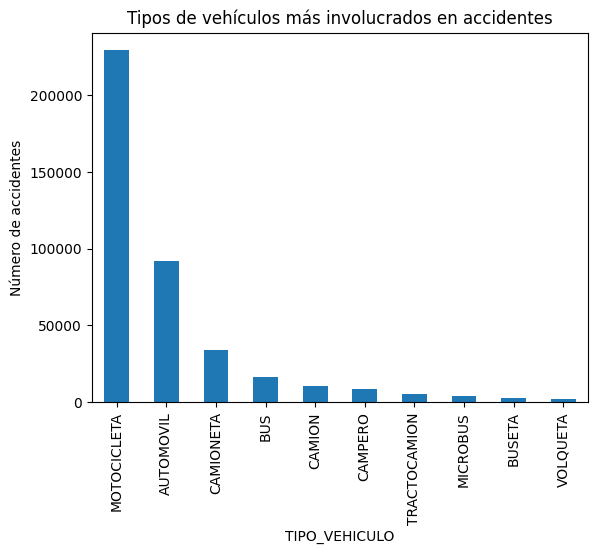

In [42]:
import matplotlib.pyplot as plt

Vehiculos_inv_Accidentes= df['TIPO_VEHICULO'].value_counts().head(10).plot(kind='bar')
plt.title("Tipos de vehículos más involucrados en accidentes")
plt.ylabel("Número de accidentes")
plt.show()

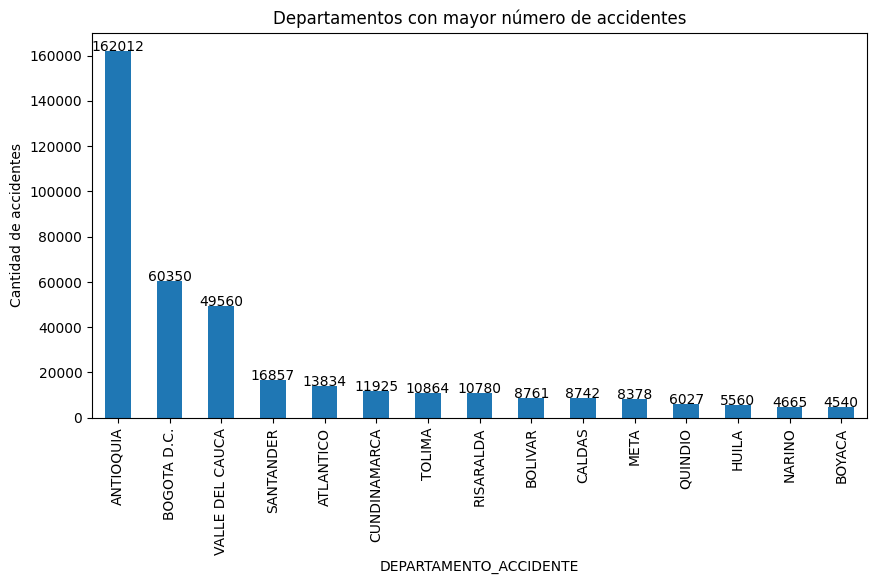

In [14]:
top_departamentos = df['DEPARTAMENTO_ACCIDENTE'].value_counts().head(15)

ax = top_departamentos.plot(kind='bar', figsize=(10,5))
plt.title("Departamentos con mayor número de accidentes")
plt.ylabel("Cantidad de accidentes")
for i, v in enumerate(top_departamentos):
    ax.text(i, v + 50, str(v), ha='center')
plt.show()

In [15]:
df_antioquia = df[df['DEPARTAMENTO_ACCIDENTE'] == 'ANTIOQUIA']

In [16]:
df_antioquia.shape

(162012, 13)

In [17]:
vehiculos_antioquia = df_antioquia['TIPO_VEHICULO'].value_counts().head(10)

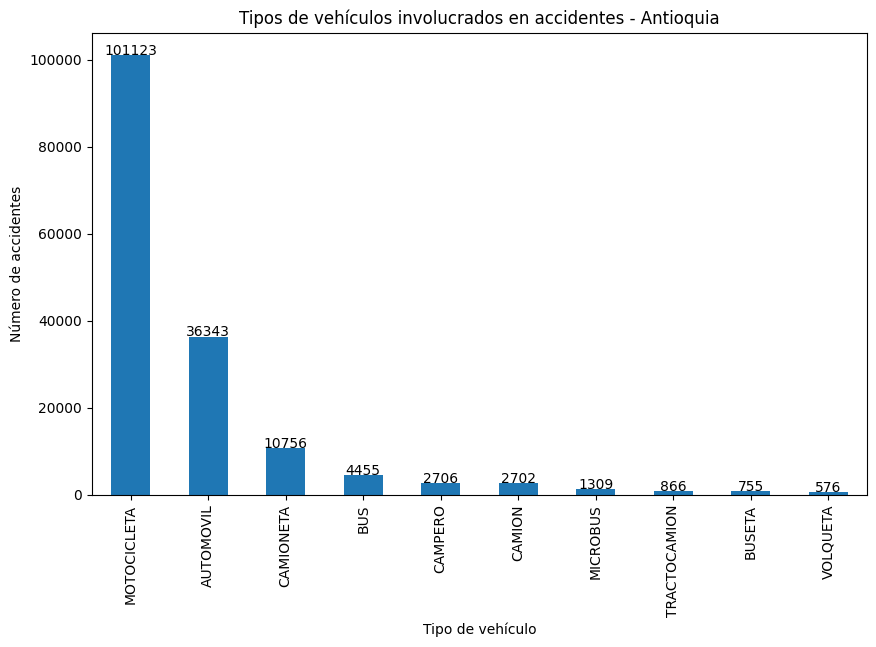

In [18]:
plt.figure(figsize=(10,6))
ax = vehiculos_antioquia.plot(kind='bar')

plt.title("Tipos de vehículos involucrados en accidentes - Antioquia")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Número de accidentes")

# agregar valores encima de las barras
for i, v in enumerate(vehiculos_antioquia):
    ax.text(i, v + 50, str(v), ha='center')

plt.show()

In [19]:
gravedad_antioquia = df_antioquia['GRAVEDAD_ACCIDENTE'].value_counts()

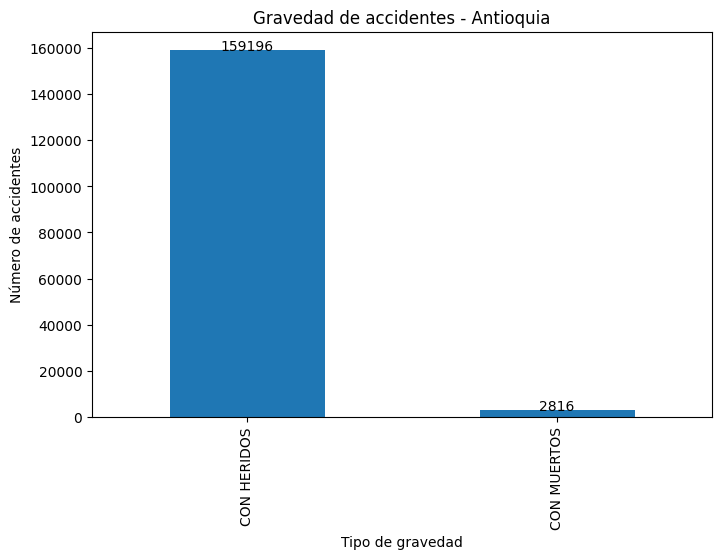

In [20]:
plt.figure(figsize=(8,5))
ax = gravedad_antioquia.plot(kind='bar')

plt.title("Gravedad de accidentes - Antioquia")
plt.xlabel("Tipo de gravedad")
plt.ylabel("Número de accidentes")

for i, v in enumerate(gravedad_antioquia):
    ax.text(i, v + 50, str(v), ha='center')

plt.show()

In [21]:
top_departamentos = df['DEPARTAMENTO_ACCIDENTE'].value_counts().head(10)

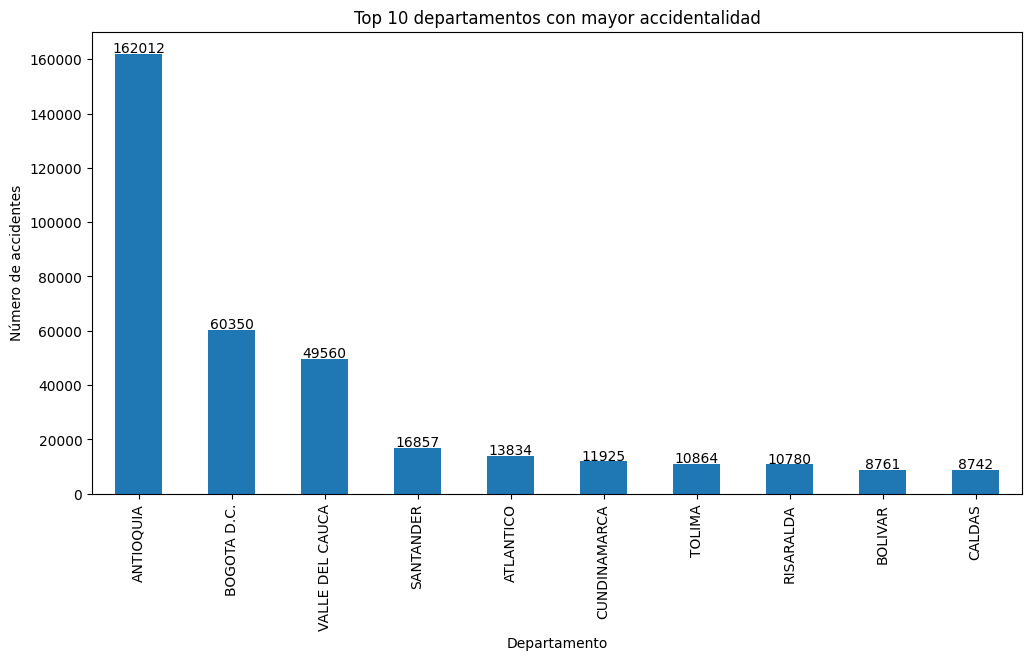

In [22]:
plt.figure(figsize=(12,6))
ax = top_departamentos.plot(kind='bar')

plt.title("Top 10 departamentos con mayor accidentalidad")
plt.xlabel("Departamento")
plt.ylabel("Número de accidentes")

for i, v in enumerate(top_departamentos):
    ax.text(i, v + 500, str(v), ha='center')

plt.show()

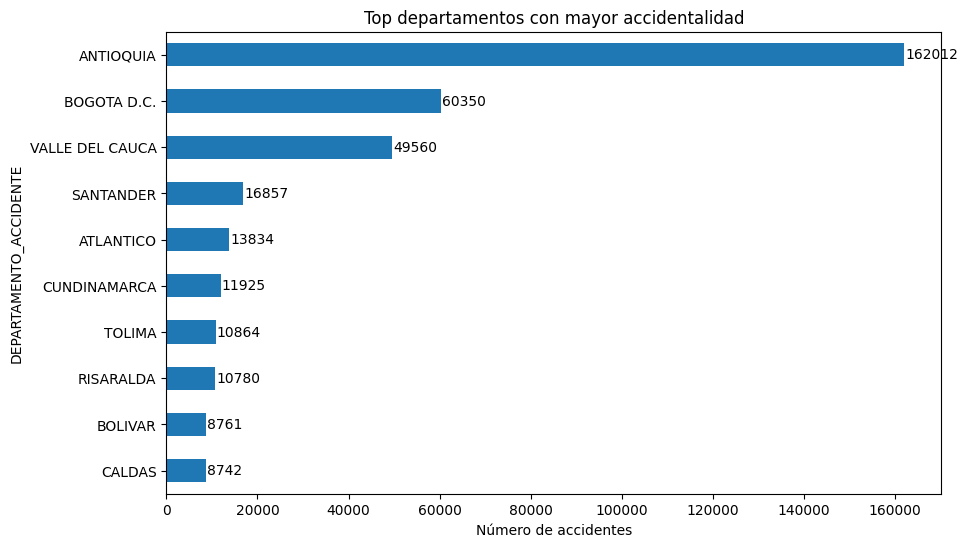

In [23]:
plt.figure(figsize=(10,6))
ax = top_departamentos.sort_values().plot(kind='barh')

plt.title("Top departamentos con mayor accidentalidad")
plt.xlabel("Número de accidentes")

for i, v in enumerate(top_departamentos.sort_values()):
    ax.text(v + 200, i, str(v), va='center')

plt.show()

In [24]:
df['SEVERIDAD'] = df['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: 1 if x == 'CON MUERTOS' else 0
)

In [25]:
df['SEVERIDAD'].value_counts()

SEVERIDAD
0    385881
1     20659
Name: count, dtype: int64

In [26]:
y = df['SEVERIDAD']

In [27]:
X = df[['TIPO_VEHICULO',
        'EDAD_VEHICULO',
        'MODELO_VEHICULO',
        'DEPARTAMENTO_ACCIDENTE']]

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
X.head()

,EDAD_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO_BUS,TIPO_VEHICULO_BUSETA,TIPO_VEHICULO_CAMION,TIPO_VEHICULO_CAMIONETA,TIPO_VEHICULO_CAMPERO,TIPO_VEHICULO_CARGADOR,TIPO_VEHICULO_CICLOMOTOR,TIPO_VEHICULO_COMPACTADOR,...,DEPARTAMENTO_ACCIDENTE_NARINO,DEPARTAMENTO_ACCIDENTE_NORTE DE SANTANDER,DEPARTAMENTO_ACCIDENTE_PUTUMAYO,DEPARTAMENTO_ACCIDENTE_QUINDIO,DEPARTAMENTO_ACCIDENTE_RISARALDA,DEPARTAMENTO_ACCIDENTE_SANTANDER,DEPARTAMENTO_ACCIDENTE_SUCRE,DEPARTAMENTO_ACCIDENTE_TOLIMA,DEPARTAMENTO_ACCIDENTE_VALLE DEL CAUCA,DEPARTAMENTO_ACCIDENTE_VICHADA
0,9.0,2017,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,20.0,2007,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,9.0,2017,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,2.0,2023,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1.0,2026,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [30]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
X.isnull().sum()

EDAD_VEHICULO                                                     21
MODELO_VEHICULO                                                    0
TIPO_VEHICULO_BUS                                                  0
TIPO_VEHICULO_BUSETA                                               0
TIPO_VEHICULO_CAMION                                               0
TIPO_VEHICULO_CAMIONETA                                            0
TIPO_VEHICULO_CAMPERO                                              0
TIPO_VEHICULO_CARGADOR                                             0
TIPO_VEHICULO_CICLOMOTOR                                           0
TIPO_VEHICULO_COMPACTADOR                                          0
TIPO_VEHICULO_CUADRICICLO                                          0
TIPO_VEHICULO_CUATRIMOTO                                           0
TIPO_VEHICULO_EXCAVADORA                                           0
TIPO_VEHICULO_FRESADORA                                            0
TIPO_VEHICULO_MAQ. AGRICOLA       

In [32]:
X['EDAD_VEHICULO'] = X['EDAD_VEHICULO'].fillna(X['EDAD_VEHICULO'].median())

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

<Axes: xlabel='TIPO_VEHICULO'>

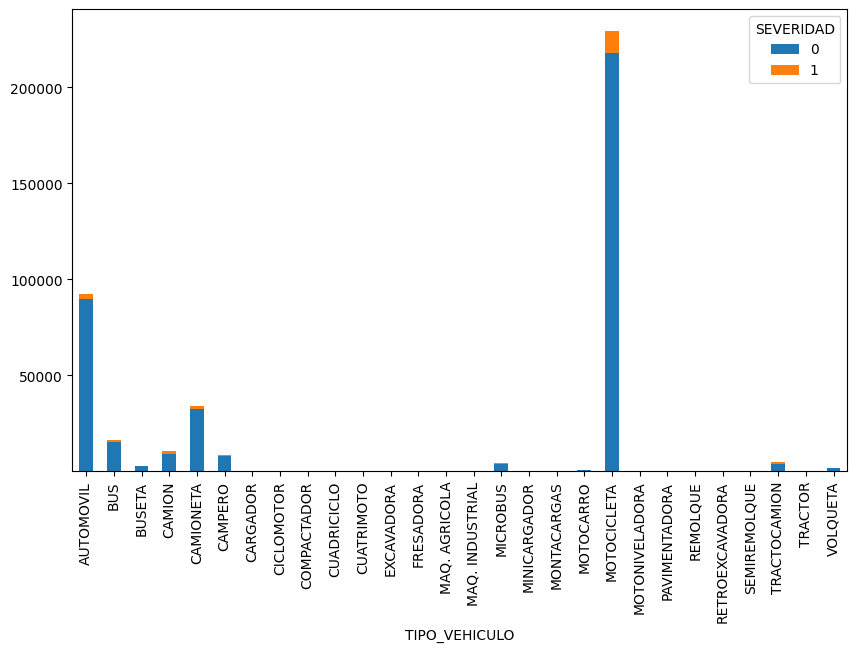

In [34]:
tabla = pd.crosstab(df['TIPO_VEHICULO'], df['SEVERIDAD'])
tabla.to_csv("../data/external/severidad_por_vehiculo.csv")

tabla.plot(kind='bar', stacked=True, figsize=(10,6))

<Axes: xlabel='MES'>

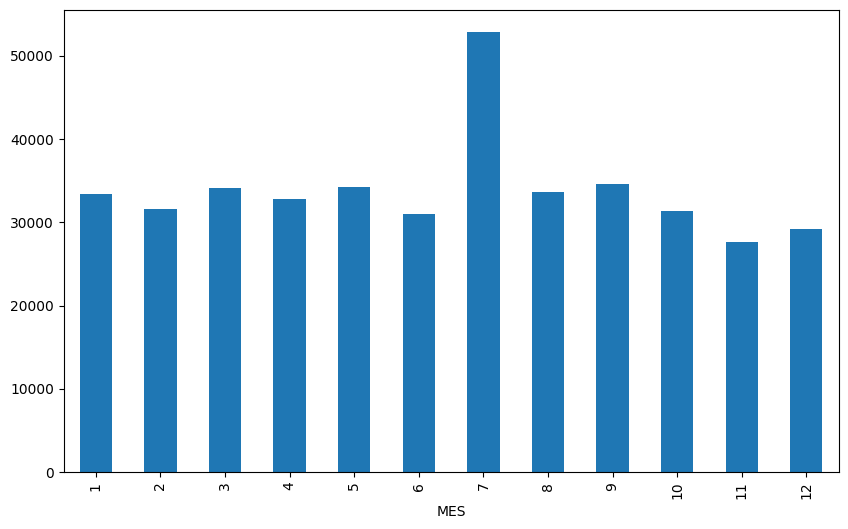

In [35]:
accidentes_mes = df['MES'].value_counts().sort_index()
accidentes_mes.to_csv("../data/external/accidentes_por_mes.csv")

accidentes_mes.plot(kind='bar', figsize=(10,6))


<Axes: xlabel='DEPARTAMENTO_ACCIDENTE'>

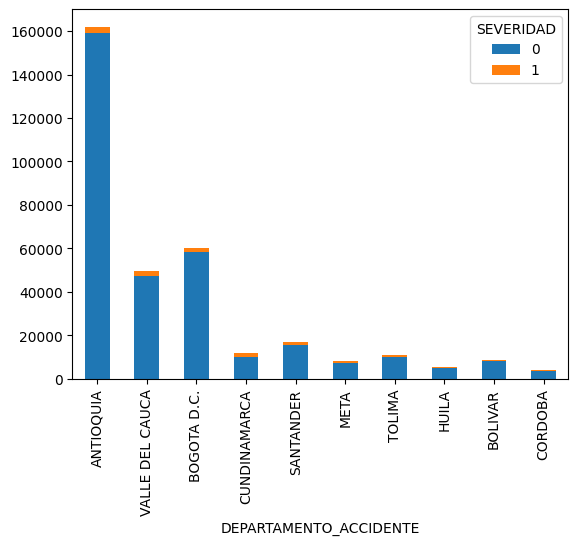

In [36]:
tabla_dpto = pd.crosstab(df['DEPARTAMENTO_ACCIDENTE'], df['SEVERIDAD'])
tabla_dpto.to_csv("../data/external/severidad_por_departamento.csv")

tabla_dpto.sort_values(by=1, ascending=False).head(10).plot(kind='bar', stacked=True)

In [37]:
kpis = {
    "Total accidentes": len(df),
    "Accidentes severos": int(df['SEVERIDAD'].sum()),
    "Tasa de severidad": round(df['SEVERIDAD'].mean(), 2),
    "Vehículo más frecuente": df['TIPO_VEHICULO'].mode()[0],
    "Departamento más crítico": df['DEPARTAMENTO_ACCIDENTE'].mode()[0]
}

<Axes: xlabel='TIPO_VEHICULO'>

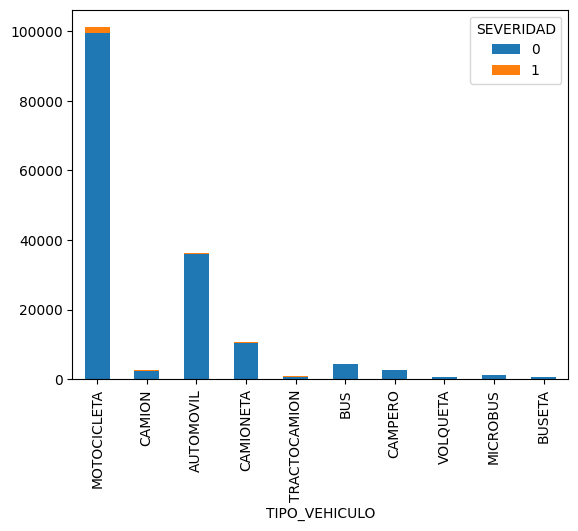

In [38]:
df_antioquia = df[df['DEPARTAMENTO_ACCIDENTE'] == 'ANTIOQUIA']

pd.crosstab(df_antioquia['TIPO_VEHICULO'], df_antioquia['SEVERIDAD']) \
    .sort_values(by=1, ascending=False) \
    .head(10) \
    .plot(kind='bar', stacked=True)

In [39]:
df['SEVERIDAD'].value_counts()

SEVERIDAD
0    385881
1     20659
Name: count, dtype: int64

In [45]:
df_antioquia = df[df["DEPARTAMENTO_ACCIDENTE"] == "ANTIOQUIA"]

In [46]:
top_municipios = df_antioquia["MUNICIPIO_ACCIDENTE"].value_counts().head(15).index

df_antioquia["MUNICIPIO_GROUP"] = df_antioquia["MUNICIPIO_ACCIDENTE"].apply(
    lambda x: x if x in top_municipios else "OTROS"
)

C:\Users\caror\AppData\Local\Temp\ipykernel_19892\1298631090.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_antioquia["MUNICIPIO_GROUP"] = df_antioquia["MUNICIPIO_ACCIDENTE"].apply(


In [47]:
from sklearn.utils import resample

df_majority = df_antioquia[df_antioquia["SEVERIDAD"] == 0]
df_minority = df_antioquia[df_antioquia["SEVERIDAD"] == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [48]:
def clasificar_edad(x):
    if x <= 5:
        return "NUEVO"
    elif x <= 15:
        return "MEDIO"
    else:
        return "ANTIGUO"

df_balanced["EDAD_CAT"] = df_balanced["EDAD_VEHICULO"].apply(clasificar_edad)

In [49]:
features = [
    "TIPO_VEHICULO",
    "EDAD_CAT",
    "MES",
    "MUNICIPIO_GROUP"
]

In [50]:
df_model = pd.get_dummies(df_balanced[features], drop_first=True)

y = df_balanced["SEVERIDAD"]